### Dataset Description

The original dataset consists of time-series measurements capturing environmental and solar energy variables. Each row represents a specific date with corresponding meteorological readings and solar power output. The dataset includes the following columns:

- **Date**  
  The calendar date of the recorded observation. This is the temporal index for the dataset and is used to analyze trends, seasonal patterns, and time-based relationships in the data.

- **AvgTemperture**  
  The average ambient air temperature recorded on that date. Temperature is a key factor influencing solar power generation, as higher temperatures can affect photovoltaic (PV) efficiency.

- **AverageDew(point via humidity)**  
  The average dew point value, calculated based on humidity levels. Dew point reflects moisture content in the air, which may impact solar irradiance due to atmospheric water vapor.

- **Humidity**  
  The relative humidity (%) measured on the given date. Higher humidity levels generally indicate cloudier conditions, reducing solar intensity and PV output.

- **Wind**  
  The average wind speed for the day. Wind can influence solar production indirectly by affecting temperature and cloud movement, and directly by cooling PV panels, potentially improving efficiency.

- **Pressure**  
  The atmospheric pressure reading (typically measured in inches of mercury or millibars). Pressure patterns can be linked to weather systems, aiding in interpretation of cloudy vs. clear conditions.

- **Solar(PV)**  
  The recorded solar photovoltaic power output for that date. This is the target variable in modeling and represents the amount of solar energy generated.

Overall, the dataset provides a combination of meteorological measurements and solar power output values suitable for forecasting, correlation analysis, seasonal trend detection, and machine learning experiments on energy prediction.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, norm
import itertools


In [2]:
raw_df = pd.read_csv("./SolarPanelData.csv").drop(columns=['Unnamed: 0'])
df = raw_df.copy()
df.head()

,Date,AvgTemperture,AverageDew(point via humidity),Humidity,Wind,Pressure,Solar(PV)
0,4/1/2022,87.9,31.3,13.4,5.7,29.2,19.010857
1,4/3/2022,90.2,34.0,14.2,6.6,29.1,16.885714
2,4/4/2022,93.2,31.4,11.8,8.8,29.1,19.627429
3,4/5/2022,92.5,24.9,9.4,8.0,29.1,18.929429
4,4/6/2022,91.2,18.9,7.8,9.4,29.2,18.934000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            398 non-null    object 
 1   AvgTemperture                   398 non-null    float64
 2   AverageDew(point via humidity)  398 non-null    float64
 3   Humidity                        398 non-null    float64
 4   Wind                            398 non-null    float64
 5   Pressure                        398 non-null    float64
 6   Solar(PV)                       398 non-null    float64
dtypes: float64(6), object(1)
memory usage: 21.9+ KB


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df['Date'].dtype

dtype('<M8[ns]')

In [6]:
df = df.sort_values("Date")

In [7]:
print(df['Date'].min())
print(df['Date'].max())

2021-04-01 00:00:00
2022-04-29 00:00:00


In [8]:
df.describe()

,Date,AvgTemperture,AverageDew(point via humidity),Humidity,Wind,Pressure,Solar(PV)
count,398,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,2021-10-26 08:22:54.874371584,81.846482,36.754020,22.968090,10.146734,29.183040,24.375258
min,2021-04-01 00:00:00,51.100000,15.300000,7.400000,4.400000,28.900000,8.581429
25%,2021-07-15 06:00:00,70.850000,29.625000,15.625000,8.300000,29.100000,17.687714
50%,2021-10-23 12:00:00,85.050000,37.250000,20.500000,10.100000,29.200000,23.476000
75%,2022-02-14 18:00:00,93.400000,44.000000,28.975000,12.000000,29.300000,31.729571
max,2022-04-29 00:00:00,102.700000,63.900000,47.700000,17.100000,29.600000,40.038857
std,NaN,13.613097,8.906835,9.756598,2.509152,0.140241,7.507561


In [9]:
df['Pressure'].value_counts().sort_index()

Pressure
28.90      3
29.00     65
29.10    129
29.20     74
29.30     67
29.40     47
29.45      1
29.50     11
29.60      1
Name: count, dtype: int64

In [10]:
columns = list(df.columns)
columns

['Date',
 'AvgTemperture',
 'AverageDew(point via humidity)',
 'Humidity',
 'Wind',
 'Pressure',
 'Solar(PV)']

In [11]:
for col in columns:
    if col != "Date":
        print(f"{col}: {len(df[col].unique())}")

AvgTemperture: 260
AverageDew(point via humidity): 232
Humidity: 225
Wind: 106
Pressure: 9
Solar(PV): 368


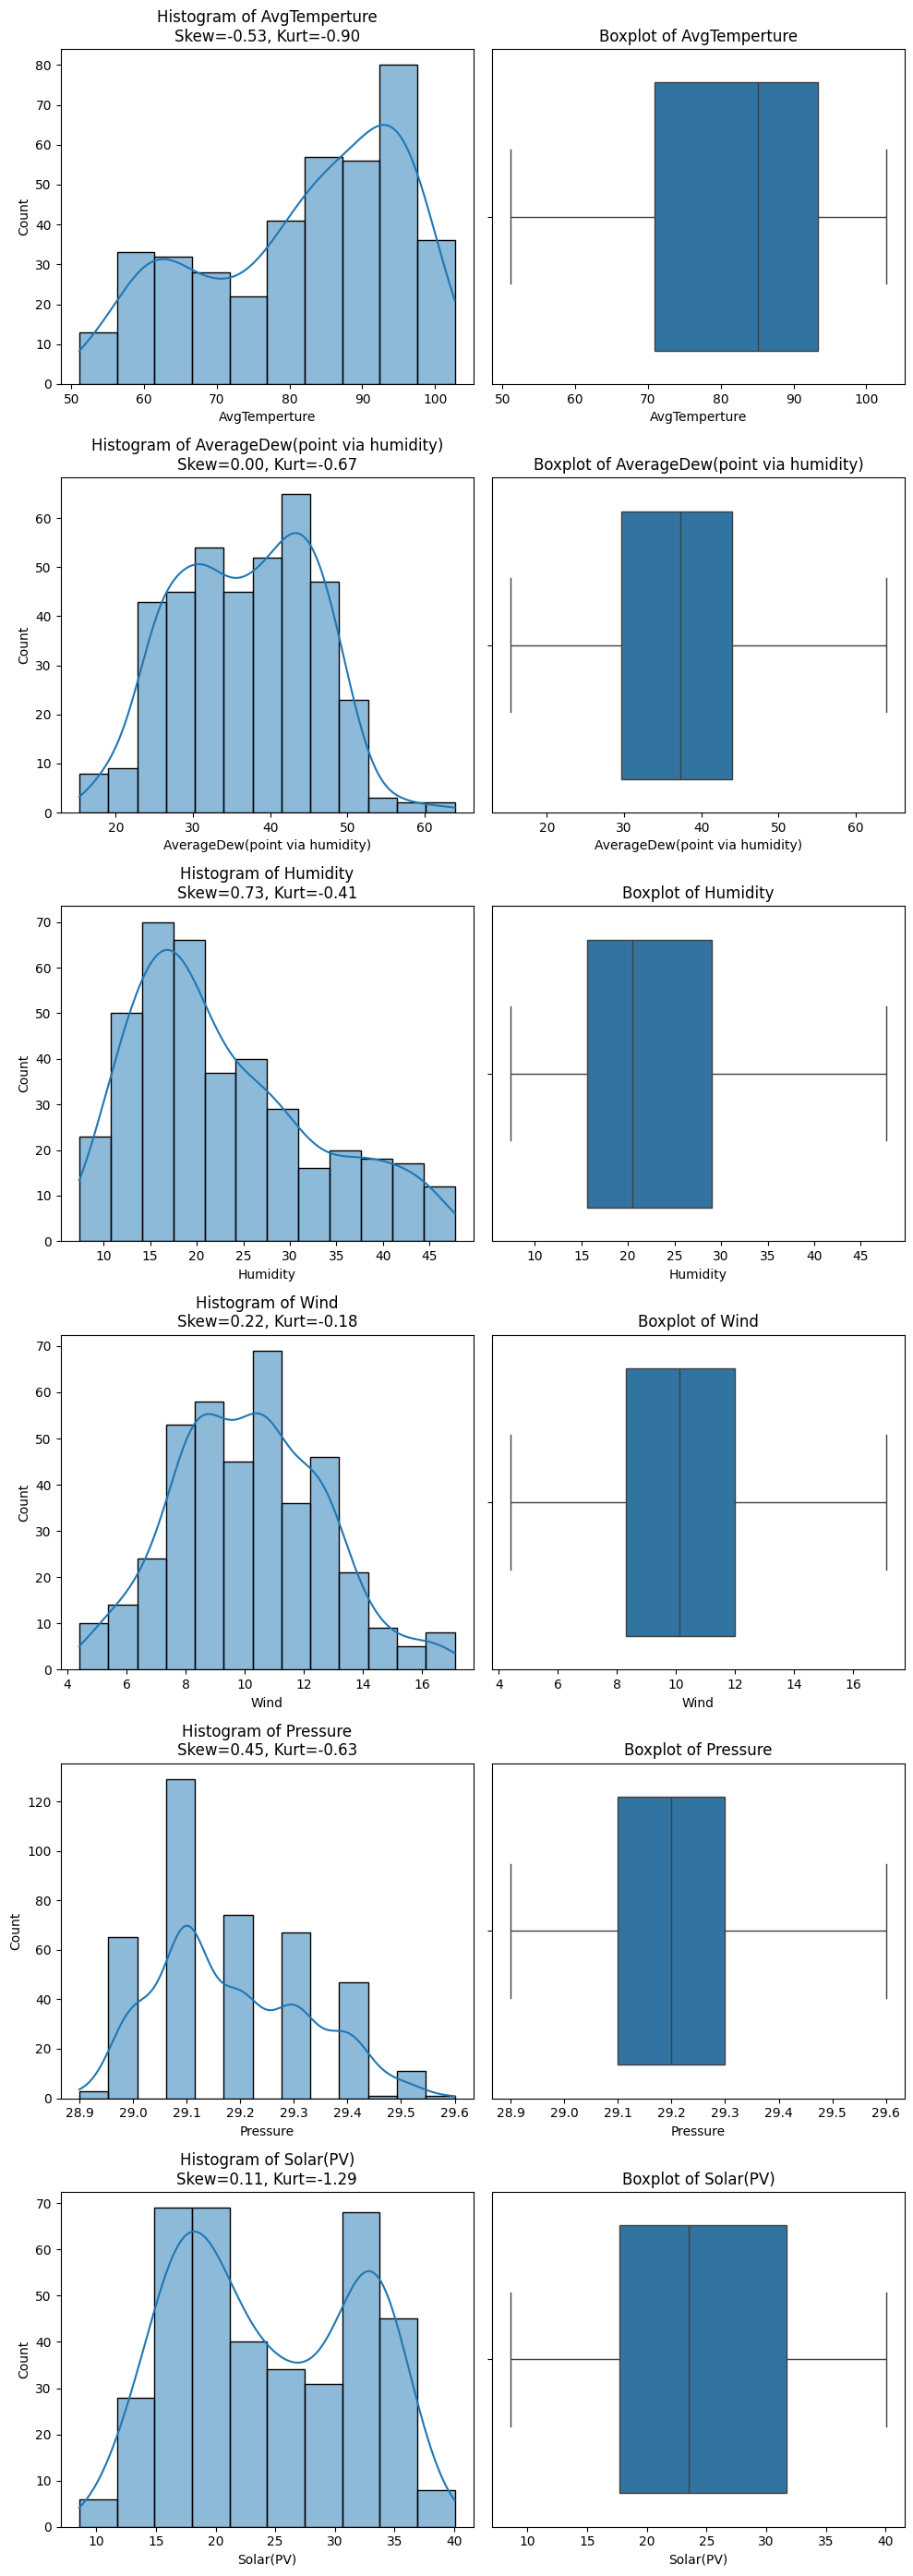

In [12]:
fig, axes = plt.subplots(len(columns)-1, 2, figsize=(10, 4*len(columns)))

row = 0
for col in columns:
    if col != "Date":
        
        skew_val = df[col].skew()
        kurt_val = df[col].kurt()
        
        sns.histplot(df[col], ax=axes[row, 0], kde=True)
        axes[row, 0].set_title(
            f"Histogram of {col}\nSkew={skew_val:.2f}, Kurt={kurt_val:.2f}"
        )

        sns.boxplot(x=df[col], ax=axes[row, 1])
        axes[row, 1].set_title(f"Boxplot of {col}")

        row += 1

plt.tight_layout()
plt.show()


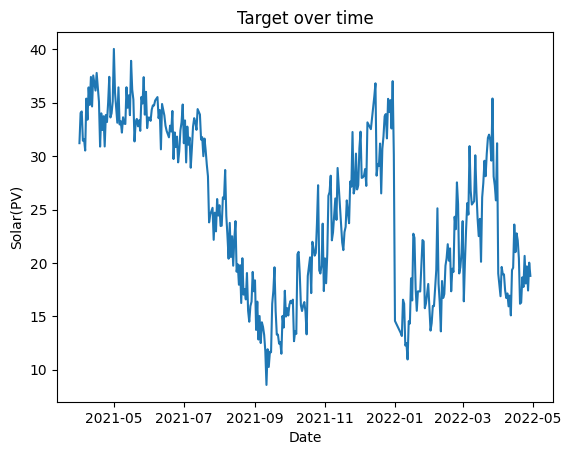

In [13]:
plt.plot(df['Date'], df['Solar(PV)'])
plt.xlabel("Date")
plt.ylabel("Solar(PV)")
plt.title("Target over time")
plt.show()

In [14]:
def get_season(date):
    m = date.month
    if m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    elif m in [9, 10, 11]:
        return "Fall"
    else:
        return "Winter"

In [15]:
df['Season'] = df['Date'].apply(get_season)

In [16]:
df[['Date', 'Season']].sample(10)

,Date,Season
48,2022-04-22,Spring
236,2021-09-15,Fall
161,2021-12-28,Winter
330,2021-06-22,Summer
88,2022-02-03,Winter
108,2022-02-23,Winter
56,2022-03-01,Spring
324,2021-06-15,Summer
284,2021-07-02,Summer
126,2022-01-17,Winter


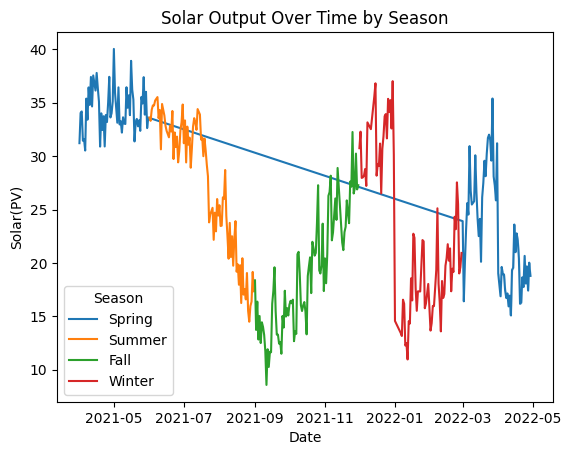

In [17]:
sns.lineplot(data=df, x="Date", y="Solar(PV)", hue="Season")
plt.title("Solar Output Over Time by Season")
plt.show()


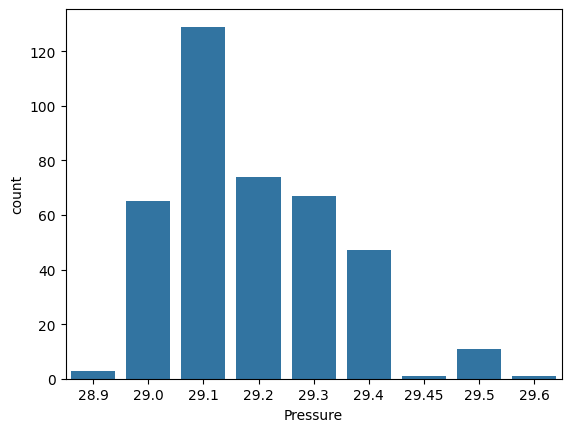

In [18]:
sns.countplot(x=df['Pressure'])
plt.show()

In [19]:
df['PressureBin'] = pd.qcut(df['Pressure'], q=5, duplicates='drop')

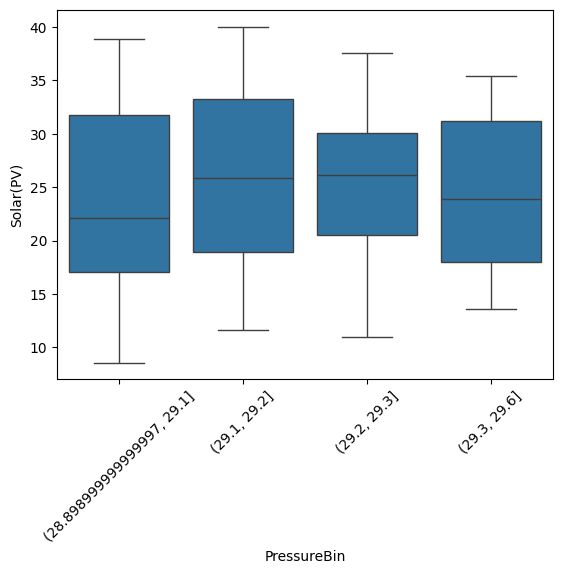

In [20]:
sns.boxplot(x='PressureBin', y='Solar(PV)', data=df)
plt.xticks(rotation=45)
plt.show()


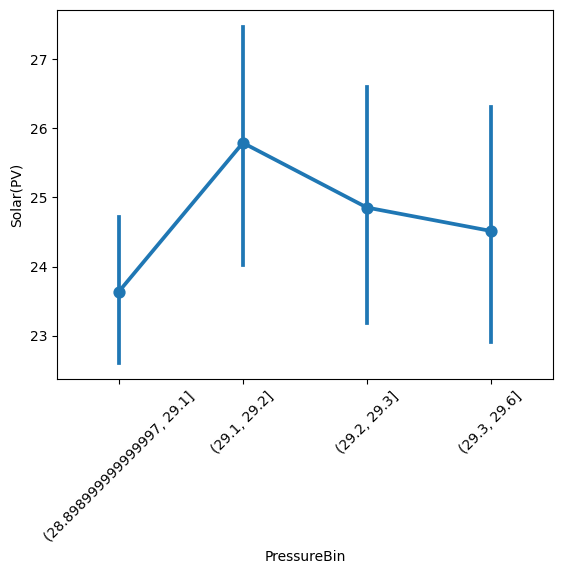

In [21]:
sns.pointplot(x='PressureBin', y='Solar(PV)', data=df, errorbar=('ci', 95))
plt.xticks(rotation=45)
plt.show()


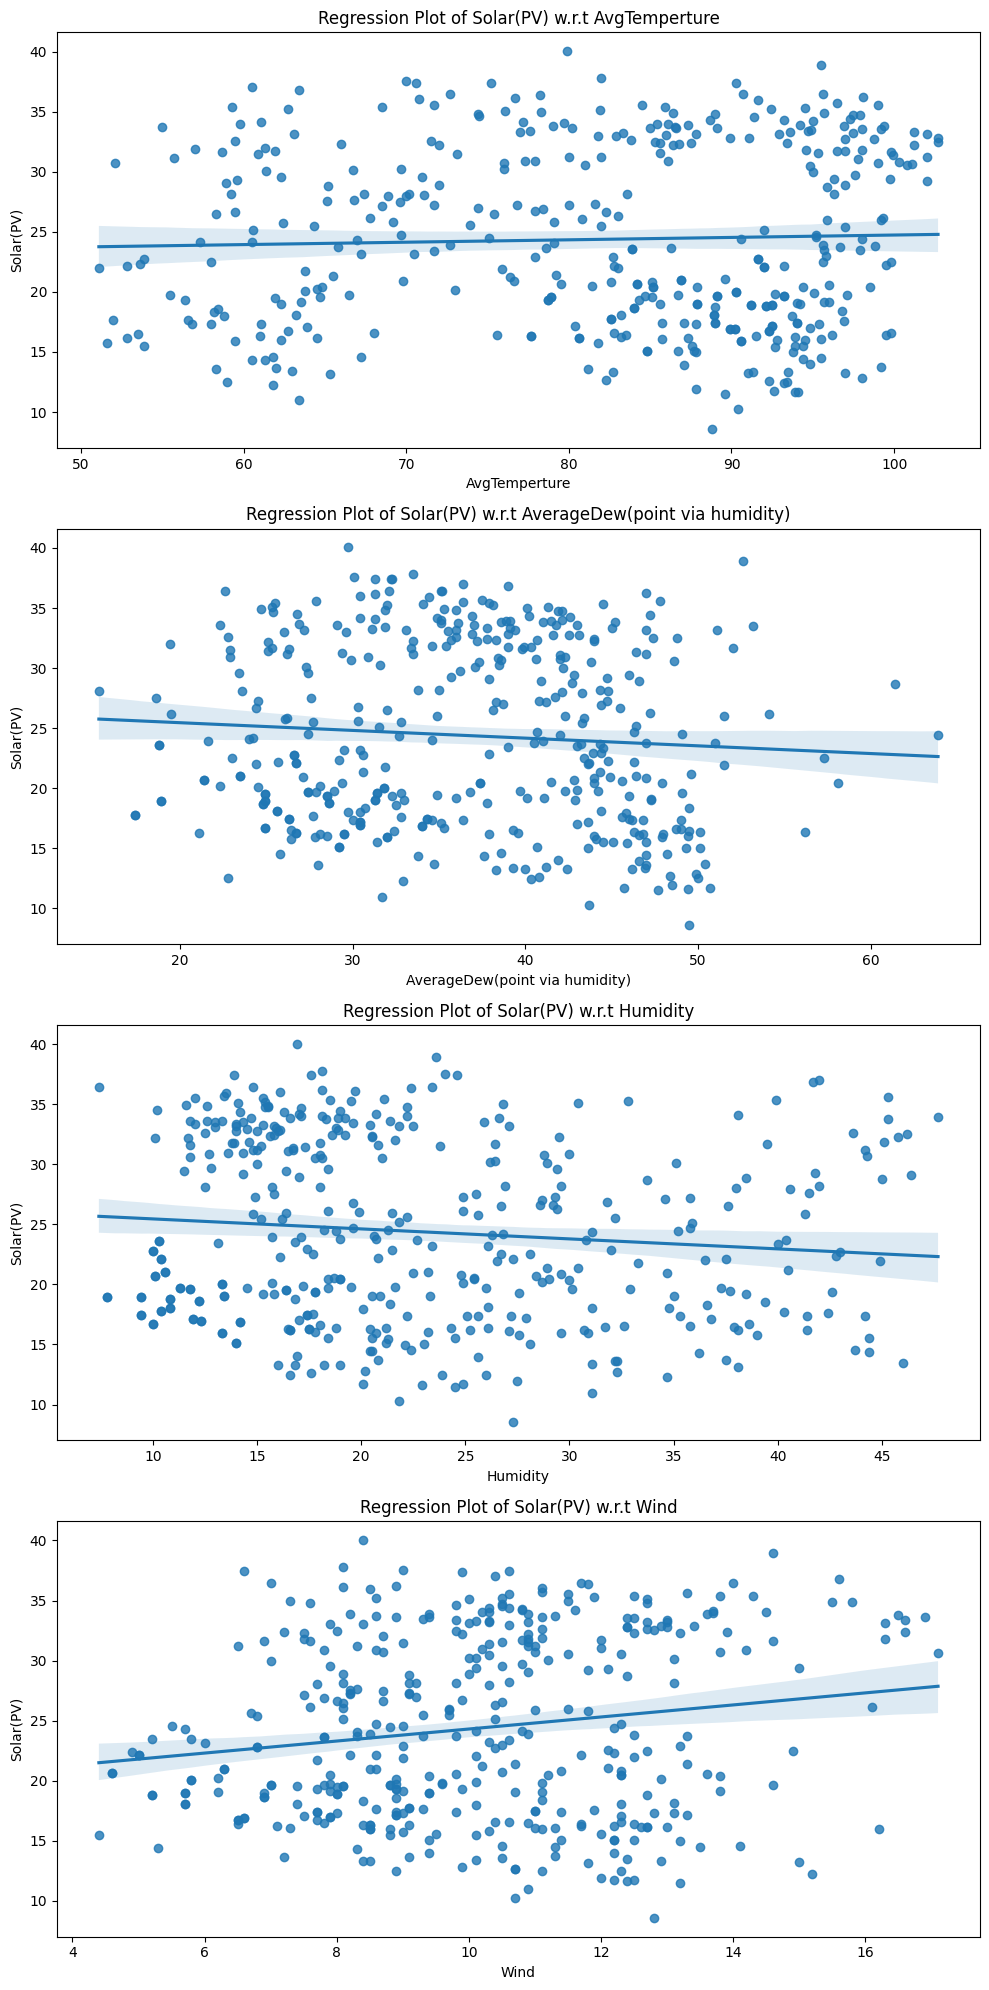

In [22]:
fig, axes = plt.subplots(len(columns)-3, 1, figsize=(10, 20))

row = 0
for col in columns:
    if col not in  ['Date', 'Pressure', 'Solar(PV)']:
        sns.regplot(x=df[col], y=df['Solar(PV)'], ax=axes[row])
        axes[row].set_title(f"Regression Plot of Solar(PV) w.r.t {col}")

        row += 1

plt.tight_layout()
plt.show()

In [23]:
df.columns

Index(['Date', 'AvgTemperture', 'AverageDew(point via humidity)', 'Humidity',
       'Wind', 'Pressure', 'Solar(PV)', 'Season', 'PressureBin'],
      dtype='object')

In [ ]:
cols_corrs = ['AvgTemperture', 'AverageDew(point via humidity)', 'Humidity',
            'Wind', 'Solar(PV)', 'Season', 'PressureBin']

num_cols = [
    'AvgTemperture',
    'AverageDew(point via humidity)',
    'Humidity',
    'Wind',s
    'Solar(PV)'
]

cat_cols = [
    'Season',
    'PressureBin'
]
df_sub = df[cols_corrs].copy()

In [25]:

cov_matrix = df_sub[num_cols].cov()
print("COVARIANCE MATRIX")
display(cov_matrix)


COVARIANCE MATRIX


,AvgTemperture,AverageDew(point via humidity),Humidity,Wind,Solar(PV)
AvgTemperture,185.316398,56.149939,-97.565591,4.516890,3.687807
AverageDew(point via humidity),56.149939,79.331709,19.683340,7.761021,-5.092046
Humidity,-97.565591,19.683340,95.191196,2.206180,-7.919480
Wind,4.516890,7.761021,2.206180,6.295846,3.154827
Solar(PV),3.687807,-5.092046,-7.919480,3.154827,56.363466


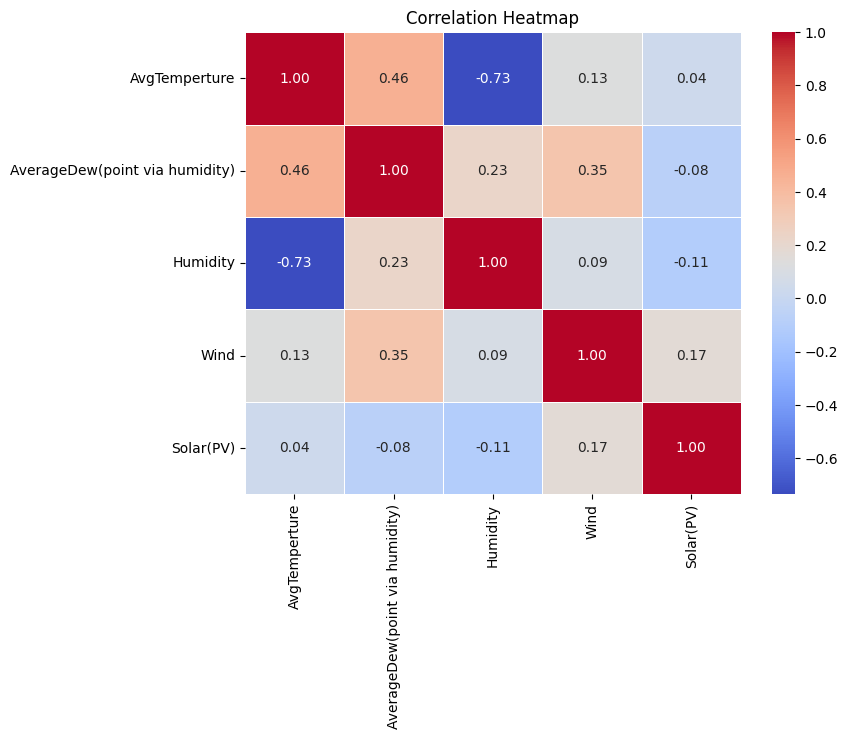

In [26]:
corr_matrix = df_sub[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix, 
    annot=True,      
    fmt=".2f",       
    cmap="coolwarm", 
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()


In [27]:
table = pd.crosstab(df_sub['Season'], df_sub['PressureBin'])
chi2, p, dof, expected = chi2_contingency(table)

n = table.sum().sum()
rho_t = np.sqrt(chi2 / (n * np.sqrt(dof)))

print("\nCHI-SQUARE TEST (Season vs PressureBin)")
print("Chi2:", chi2)
print("p-value:", p)
print("DOF:", dof)
print("rho_t:", rho_t)



CHI-SQUARE TEST (Season vs PressureBin)
Chi2: 248.48767054928874
p-value: 2.080716996744533e-48
DOF: 9
rho_t: 0.4561947247894286


In [28]:
def ztest_two_groups(x, y):
    x = np.array(x.dropna())
    y = np.array(y.dropna())
    
    mean_x, mean_y = x.mean(), y.mean()
    var_x, var_y = x.var(ddof=1), y.var(ddof=1)
    n_x, n_y = len(x), len(y)
    
    z = (mean_x - mean_y) / np.sqrt(var_x/n_x + var_y/n_y)
    
    p = 2 * (1 - norm.cdf(abs(z)))
    
    return z, p


In [29]:
results = []

for cat in cat_cols:
    categories = df[cat].dropna().unique()
    
    if len(categories) < 2:
        continue

    g1, g2 = categories[:2]
    
    for num in num_cols:
        x = df[df[cat] == g1][num]
        y = df[df[cat] == g2][num]
        
        z, p = ztest_two_groups(x, y)
        
        results.append({
            "Numerical": num,
            "Categorical": cat,
            "Group1": g1,
            "Group2": g2,
            "Z": z,
            "p-value": p
        })

ztest_df = pd.DataFrame(results)
display(ztest_df)


,Numerical,Categorical,Group1,Group2,Z,p-value
0,AvgTemperture,Season,Spring,Summer,-15.176121,0.000000e+00
1,AverageDew(point via humidity),Season,Spring,Summer,-16.089156,0.000000e+00
2,Humidity,Season,Spring,Summer,-1.169961,2.420165e-01
3,Wind,Season,Spring,Summer,-5.950397,2.674931e-09
4,Solar(PV),Season,Spring,Summer,-0.668663,5.037105e-01
5,AvgTemperture,PressureBin,"(29.1, 29.2]","(29.2, 29.3]",9.138762,0.000000e+00
6,AverageDew(point via humidity),PressureBin,"(29.1, 29.2]","(29.2, 29.3]",-0.394444,6.932535e-01
7,Humidity,PressureBin,"(29.1, 29.2]","(29.2, 29.3]",-7.098486,1.261213e-12
8,Wind,PressureBin,"(29.1, 29.2]","(29.2, 29.3]",-0.021983,9.824614e-01
9,Solar(PV),PressureBin,"(29.1, 29.2]","(29.2, 29.3]",0.744108,4.568113e-01


In [30]:
# results = []

# for cat in cat_cols:
    
#     categories = df[cat].dropna().unique()
    
#     for g1, g2 in itertools.combinations(categories, 2):
        
#         for num in num_cols:
#             x = df[df[cat] == g1][num]
#             y = df[df[cat] == g2][num]

#             z, p = ztest_two_groups(x, y)

#             results.append({
#                 "Numerical": num,
#                 "Categorical": cat,
#                 "Group1": g1,
#                 "Group2": g2,
#                 "Z": z,
#                 "p-value": p
#             })

# ztest_df = pd.DataFrame(results)

# display(ztest_df)


In [31]:
groups_season = [
    df_sub[df_sub['Season'] == s]['Solar(PV)']
    for s in df_sub['Season'].unique()
]

fstat, p = f_oneway(*groups_season)

print("\nANOVA (Solar(PV) vs Season)")
print("F-stat:", fstat)
print("p-value:", p)


ANOVA (Solar(PV) vs Season)
F-stat: 32.677099522890785
p-value: 6.994074352626946e-19


In [32]:
groups_press = [
    df_sub[df_sub['PressureBin'] == c]['Solar(PV)']
    for c in df_sub['PressureBin'].unique()
]

fstat, p = f_oneway(*groups_press)

print("\nANOVA (Solar(PV) vs PressureBin)")
print("F-stat:", fstat)
print("p-value:", p)



ANOVA (Solar(PV) vs PressureBin)
F-stat: 1.6109719684845811
p-value: 0.18628213207946748


In [33]:
df['Month'] = df['Date'].dt.month
df['DayOfYear'] = df['Date'].dt.dayofyear

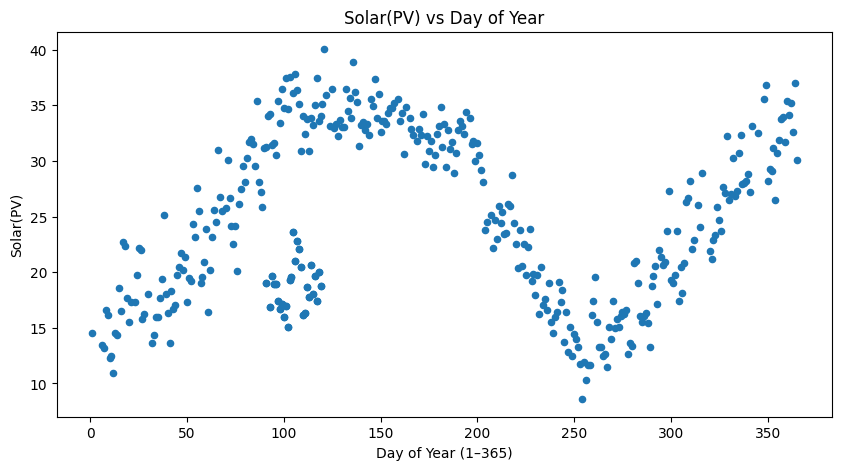

In [34]:
plt.figure(figsize=(10,5))
plt.scatter(df['DayOfYear'], df['Solar(PV)'], s=20)
plt.title("Solar(PV) vs Day of Year")
plt.xlabel("Day of Year (1–365)")
plt.ylabel("Solar(PV)")
plt.show()

In [35]:
df.columns

Index(['Date', 'AvgTemperture', 'AverageDew(point via humidity)', 'Humidity',
       'Wind', 'Pressure', 'Solar(PV)', 'Season', 'PressureBin', 'Month',
       'DayOfYear'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

In [37]:
df.columns

Index(['Date', 'AvgTemperture', 'AverageDew(point via humidity)', 'Humidity',
       'Wind', 'Pressure', 'Solar(PV)', 'Season', 'PressureBin', 'Month',
       'DayOfYear'],
      dtype='object')

In [38]:
X = df.drop(columns=['Date', 'Pressure', 'Solar(PV)'])
y = df['Solar(PV)']

In [39]:
X.head()

,AvgTemperture,AverageDew(point via humidity),Humidity,Wind,Season,PressureBin,Month,DayOfYear
369,80.0,29.4,16.7,10.9,Spring,"(29.1, 29.2]",4,91
370,79.7,31.3,18.1,10.3,Spring,"(29.1, 29.2]",4,92
371,77.2,30.4,20.7,10.8,Spring,"(29.1, 29.2]",4,93
372,73.1,25.1,17.3,9.0,Spring,"(29.1, 29.2]",4,94
373,85.6,26.3,11.8,7.6,Spring,"(29.1, 29.2]",4,95


In [40]:
x_train_val, x_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.1, random_state=42)

In [41]:
x_train['Solar_lag1'] = y_train.shift(1)
x_train['Solar_lag7'] = y_train.shift(7)

In [42]:
x_val['Solar_lag1'] = y_val.shift(1)
x_val['Solar_lag7'] = y_val.shift(7)

In [43]:
x_test['Solar_lag1'] = y_test.shift(1)
x_test['Solar_lag7'] = y_test.shift(7)

In [ ]:
train_mask = x_train[['Solar_lag1','Solar_lag7']].notna().all(axis=1)

x_train = x_train[train_mask]
y_train = y_train[train_mask]

val_mask = x_val[['Solar_lag1','Solar_lag7']].notna().all(axis=1)

x_val = x_val[val_mask]
y_val = y_val[val_mask]

test_mask = x_test[['Solar_lag1','Solar_lag7']].notna().all(axis=1)

x_test = x_test[test_mask]
y_test = y_test[test_mask]

In [45]:
x_train.columns
num_cols = [
'AvgTemperture', 'AverageDew(point via humidity)', 'Humidity', 'Wind',
'Month', 'DayOfYear', 'Solar_lag1', 'Solar_lag7'
]
cat_cols = ['Season', 'PressureBin']

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)

In [48]:
y_train_reg, y_train_class = y_train, pd.qcut(y_train, q=4, labels=False)
y_val_reg, y_val_class = y_val, pd.qcut(y_val, q=4, labels=False)
y_test_reg, y_test_class = y_test, pd.qcut(y_test, q=4, labels=False)

In [49]:
nb_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GaussianNB())
])

nb_clf.fit(x_train, y_train_class)
y_pred_nb = nb_clf.predict(x_val)

print("Naive Bayes accuracy:", accuracy_score(y_val_class, y_pred_nb))

Naive Bayes accuracy: 0.4827586206896552


In [50]:
dt_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion="entropy",
        random_state=42,
        max_depth=None
    ))
])

dt_clf.fit(x_train, y_train_class)
y_pred_dt = dt_clf.predict(x_val)

acc_dt = accuracy_score(y_val_class, y_pred_dt)
err_dt = 1 - acc_dt

print("Decision Tree accuracy:", acc_dt)
print("Decision Tree error rate:", err_dt)

Decision Tree accuracy: 0.7586206896551724
Decision Tree error rate: 0.24137931034482762


In [51]:
metrics = ["euclidean", "manhattan", "cosine"]
knn_results = []

for metric in metrics:
    knn_clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", KNeighborsClassifier(
            n_neighbors=5,
            metric=metric
        ))
    ])
    
    knn_clf.fit(x_train, y_train_class)
    y_pred_knn = knn_clf.predict(x_val)
    acc_knn = accuracy_score(y_val_class, y_pred_knn)
    knn_results.append((metric, acc_knn))

for metric, acc in knn_results:
    print(f"KNN ({metric}) accuracy:", acc)


KNN (euclidean) accuracy: 0.5172413793103449
KNN (manhattan) accuracy: 0.6206896551724138
KNN (cosine) accuracy: 0.41379310344827586


In [52]:
lda_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearDiscriminantAnalysis())
])

lda_clf.fit(x_train, y_train_class)
y_pred_lda = lda_clf.predict(x_val)

print("LDA accuracy:", accuracy_score(y_val_class, y_pred_lda))


LDA accuracy: 0.5862068965517241


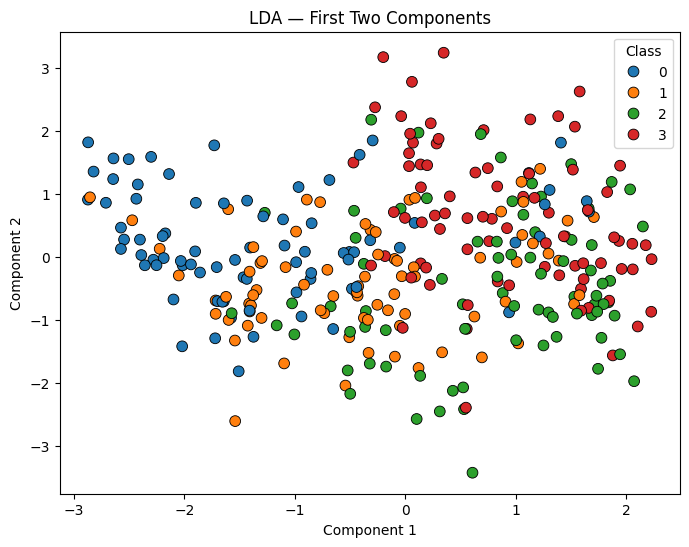

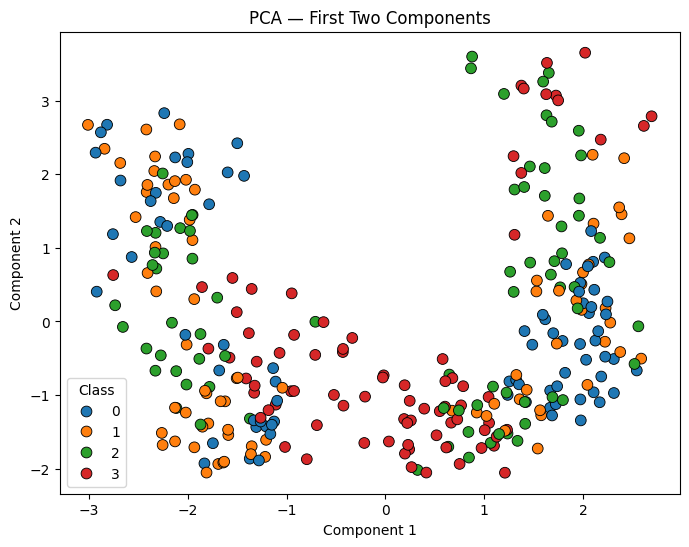

In [53]:
X_train_transformed = preprocessor.fit_transform(x_train)

lda_2 = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda_2.fit_transform(X_train_transformed, y_train_class)

pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_train_transformed)

def plot_2d(data, labels, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=data[:,0], 
        y=data[:,1], 
        hue=labels,
        palette="tab10",
        s=60,
        edgecolor="black"
    )
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(title="Class")
    plt.show()

plot_2d(X_lda, y_train_class, "LDA — First Two Components")
plot_2d(X_pca,  y_train_class, "PCA — First Two Components")


In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)

models_raw = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree (entropy)": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "LDA Classifier": LinearDiscriminantAnalysis(),
    "KNN (euclidean)": KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
    "KNN (manhattan)": KNeighborsClassifier(n_neighbors=5, metric="manhattan"),
    "KNN (cosine)": KNeighborsClassifier(n_neighbors=5, metric="cosine"),
}

results_raw = {}

for name, model in models_raw.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(x_train, y_train_class)
    y_pred = pipe.predict(x_val)
    acc = accuracy_score(y_val_class, y_pred)
    
    results_raw[name] = acc

lda_dim = LinearDiscriminantAnalysis(n_components=1)

models_lda = {
    "Naive Bayes + LDA": GaussianNB(),
    "Decision Tree + LDA": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "KNN euclidean + LDA": KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
    "KNN manhattan + LDA": KNeighborsClassifier(n_neighbors=5, metric="manhattan"),
    "KNN cosine + LDA": KNeighborsClassifier(n_neighbors=5, metric="cosine"),
}

results_lda = {}

for name, model in models_lda.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("reduce", lda_dim),
        ("model", model)
    ])
    
    pipe.fit(x_train, y_train_class)
    y_pred = pipe.predict(x_val)
    acc = accuracy_score(y_val_class, y_pred)
    
    results_lda[name] = acc

pca = PCA(n_components=5)

models_pca = {
    "Naive Bayes + PCA": GaussianNB(),
    "Decision Tree + PCA": DecisionTreeClassifier(criterion="entropy", random_state=42),
    "KNN euclidean + PCA": KNeighborsClassifier(n_neighbors=5, metric="euclidean"),
    "KNN manhattan + PCA": KNeighborsClassifier(n_neighbors=5, metric="manhattan"),
    "KNN cosine + PCA": KNeighborsClassifier(n_neighbors=5, metric="cosine"),
}

results_pca = {}

for name, model in models_pca.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("reduce", pca),
        ("model", model)
    ])
    
    pipe.fit(x_train, y_train_class)
    y_pred = pipe.predict(x_val)
    acc = accuracy_score(y_val_class, y_pred)
    
    results_pca[name] = acc

print("\n===== ACCURACY (NO DIM REDUCTION) =====")
for name, acc in results_raw.items():
    print(f"{name:30s} : {acc:.3f}")

print("\n===== ACCURACY (WITH LDA DIM REDUCTION) =====")
for name, acc in results_lda.items():
    print(f"{name:30s} : {acc:.3f}")

print("\n===== ACCURACY (WITH PCA DIM REDUCTION) =====")
for name, acc in results_pca.items():
    print(f"{name:30s} : {acc:.3f}")


# for name, model in models_lda.items():
#     pipe = Pipeline(steps=[
#         ("preprocess", preprocessor),
#         ("reduce", lda_dim),
#         ("model", model)
#     ])

#     pipe.fit(x_train, y_train_class)
#     y_pred = pipe.predict(x_val)

#     print(f"\n----- {name} -----")
#     print(classification_report(y_val_class, y_pred))

# print("\n\n===== CLASSIFICATION REPORTS (WITH PCA DIM REDUCTION) =====\n")

# pca = PCA(n_components=5)

# for name, model in models_pca.items():
#     pipe = Pipeline(steps=[
#         ("preprocess", preprocessor),
#         ("reduce", pca),
#         ("model", model)
#     ])

#     pipe.fit(x_train, y_train_class)
#     y_pred = pipe.predict(x_val)

#     print(f"\n----- {name} -----")
#     print(classification_report(y_val_class, y_pred))


===== ACCURACY (NO DIM REDUCTION) =====
Naive Bayes                    : 0.483
Decision Tree (entropy)        : 0.759
LDA Classifier                 : 0.586
KNN (euclidean)                : 0.517
KNN (manhattan)                : 0.621
KNN (cosine)                   : 0.414

===== ACCURACY (WITH LDA DIM REDUCTION) =====
Naive Bayes + LDA              : 0.379
Decision Tree + LDA            : 0.345
KNN euclidean + LDA            : 0.345
KNN manhattan + LDA            : 0.345
KNN cosine + LDA               : 0.448

===== ACCURACY (WITH PCA DIM REDUCTION) =====
Naive Bayes + PCA              : 0.414
Decision Tree + PCA            : 0.552
KNN euclidean + PCA            : 0.621
KNN manhattan + PCA            : 0.621
KNN cosine + PCA               : 0.621


In [55]:
!pip install pgmpy

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, MaximumLikelihoodEstimator
from pgmpy.estimators.StructureScore import K2
from pgmpy.inference import VariableElimination

train_bn = x_train.copy()
train_bn["target"] = y_train_class

disc_cols = [
    'AvgTemperture', 'AverageDew(point via humidity)', 'Humidity', 'Wind',
    'Month', 'DayOfYear', 'Solar_lag1', 'Solar_lag7'
]

bin_map = {}

for col in disc_cols:
    _, bins = pd.qcut(train_bn[col], q=5, retbins=True, duplicates='drop')
    bin_map[col] = bins

    train_bn[col] = np.digitize(train_bn[col], bins) - 1

cat_cols = ['Season', 'PressureBin', 'target']
for col in cat_cols:
    train_bn[col] = train_bn[col].astype('category').cat.codes


score = K2(train_bn)
hc = HillClimbSearch(train_bn)
best_model = hc.estimate(scoring_method=score)

print("Learned edges:", best_model.edges())


model = DiscreteBayesianNetwork(best_model.edges())
model.fit(train_bn, estimator=MaximumLikelihoodEstimator)
inference = VariableElimination(model)

val_bn = x_val.copy()

for col in disc_cols:
    bins = bin_map[col]
    val_bn[col] = np.digitize(val_bn[col], bins) - 1

for col in disc_cols:
    n_states = train_bn[col].nunique()
    val_bn[col] = val_bn[col].clip(0, n_states - 1)

for col in ['Season', 'PressureBin']:
    val_bn[col] = val_bn[col].astype('category').cat.codes


def predict_bnn(df):
    preds = []
    for _, row in df.iterrows():
        q = inference.query(["target"], evidence=row.to_dict())
        probs = q.values
        preds.append(np.argmax(probs))
    return np.array(preds)

bnn_preds = predict_bnn(val_bn)
bnn_acc = accuracy_score(y_val_class.astype('category').cat.codes, bnn_preds)

print("\nBNN Validation Accuracy:", bnn_acc)



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'AvgTemperture': 'N', 'AverageDew(point via humidity)': 'N', 'Humidity': 'N', 'Wind': 'N', 'Season': 'N', 'PressureBin': 'N', 'Month': 'N', 'DayOfYear': 'N', 'Solar_lag1': 'N', 'Solar_lag7': 'N', 'target': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'AvgTemperture': 'N', 'AverageDew(point via humidity)': 'N', 'Humidity': 'N', 'Wind': 'N', 'Season': 'N', 'PressureBin': 'N', 'Month': 'N', 'DayOfYear': 'N', 'Solar_lag1': 'N', 'Solar_lag7': 'N', 'target': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'AvgTemperture': 'N', 'AverageDew(point via humidity)': 'N', 'Humidity': 'N', 'Wind': 'N', 'Season': 'N', 'PressureBin': 'N', 'Month': 'N', 'DayOfYear': 'N', 'Solar_lag1': 'N', 'Solar_lag7': 'N', 'target': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'AvgTemperture': 'N', 'AverageDew(point via humidity)': 'N', 'Humidity': 'N', 'Wind': 'N', 'Season': 'N', 'PressureBin': 'N', 'Month': 'N', 'DayOfYear': 'N', 'Solar_lag1': 'N', 'Solar_lag7': 'N', 'target': 'N'}


Learned edges: [('AvgTemperture', 'Humidity'), ('AvgTemperture', 'AverageDew(point via humidity)'), ('Humidity', 'AverageDew(point via humidity)'), ('Wind', 'AvgTemperture'), ('Wind', 'Humidity'), ('Wind', 'AverageDew(point via humidity)'), ('Wind', 'target'), ('Wind', 'PressureBin'), ('Wind', 'Season'), ('Wind', 'DayOfYear'), ('Wind', 'Month'), ('Season', 'AvgTemperture'), ('Season', 'Humidity'), ('Season', 'AverageDew(point via humidity)'), ('Season', 'target'), ('Season', 'DayOfYear'), ('Season', 'Month'), ('PressureBin', 'AvgTemperture'), ('PressureBin', 'Humidity'), ('PressureBin', 'AverageDew(point via humidity)'), ('PressureBin', 'target'), ('PressureBin', 'DayOfYear'), ('PressureBin', 'Month'), ('PressureBin', 'Season'), ('Month', 'AvgTemperture'), ('Month', 'Humidity'), ('Month', 'AverageDew(point via humidity)'), ('Month', 'DayOfYear'), ('DayOfYear', 'AvgTemperture'), ('DayOfYear', 'Humidity'), ('DayOfYear', 'AverageDew(point via humidity)'), ('Solar_lag1', 'AvgTemperture'), 

d:\Projects\.venv\Lib\site-packages\pgmpy\factors\discrete\DiscreteFactor.py:489: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())


In [56]:
X_full = pd.concat([x_train, x_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train_class, y_val_class], axis=0).reset_index(drop=True)

In [57]:
dt_clf = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", dt_clf)
])

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X_full,
    y_full,
    cv=kf,
    scoring="accuracy"
)

print(f"\n=== {k}-Fold Cross Validation Results (Decision Tree, entropy) ===")
print("Fold accuracies :", np.round(scores, 3))
print("Mean accuracy   :", np.round(np.mean(scores), 3))
print("Std deviation   :", np.round(np.std(scores), 3))


=== 5-Fold Cross Validation Results (Decision Tree, entropy) ===
Fold accuracies : [0.623 0.609 0.696 0.652 0.618]
Mean accuracy   : 0.639
Std deviation   : 0.032


In [58]:
model = DecisionTreeClassifier(criterion="entropy", random_state=42)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model)
])


pipeline.fit(x_train, y_train_class)

y_pred_train = pipeline.predict(x_train)
y_pred_val = pipeline.predict(x_val)


print(f"Accuracy Score (Train): {accuracy_score(y_train_class, y_pred_train)}")
print(f"Accuracy Score (Val): {accuracy_score(y_val_class, y_pred_val)}")

Accuracy Score (Train): 1.0
Accuracy Score (Val): 0.7586206896551724


In [59]:
y_pred = pipeline.predict(x_test)
y_prob = pipeline.predict_proba(x_test)[:, 1]

CONFUSION MATRIX


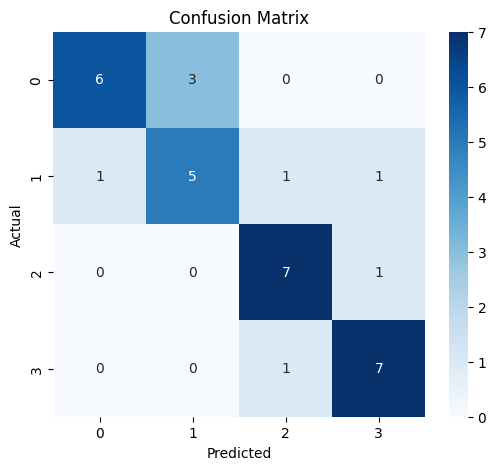

ACCURACY: 0.7575757575757576
ERROR RATE: 0.24242424242424243
PRECISION: 0.7623857623857624
RECALL: 0.7575757575757576
F1 (F-measure): 0.7553475935828876


In [60]:
cm = confusion_matrix(y_test_class, y_pred)

acc = accuracy_score(y_test_class, y_pred)
err = 1 - acc
prec = precision_score(y_test_class, y_pred, average="weighted")
rec = recall_score(y_test_class, y_pred, average="weighted")
f1 = f1_score(y_test_class, y_pred, average="weighted")


print("CONFUSION MATRIX")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("ACCURACY:", acc)
print("ERROR RATE:", err)
print("PRECISION:", prec)
print("RECALL:", rec)
print("F1 (F-measure):", f1)

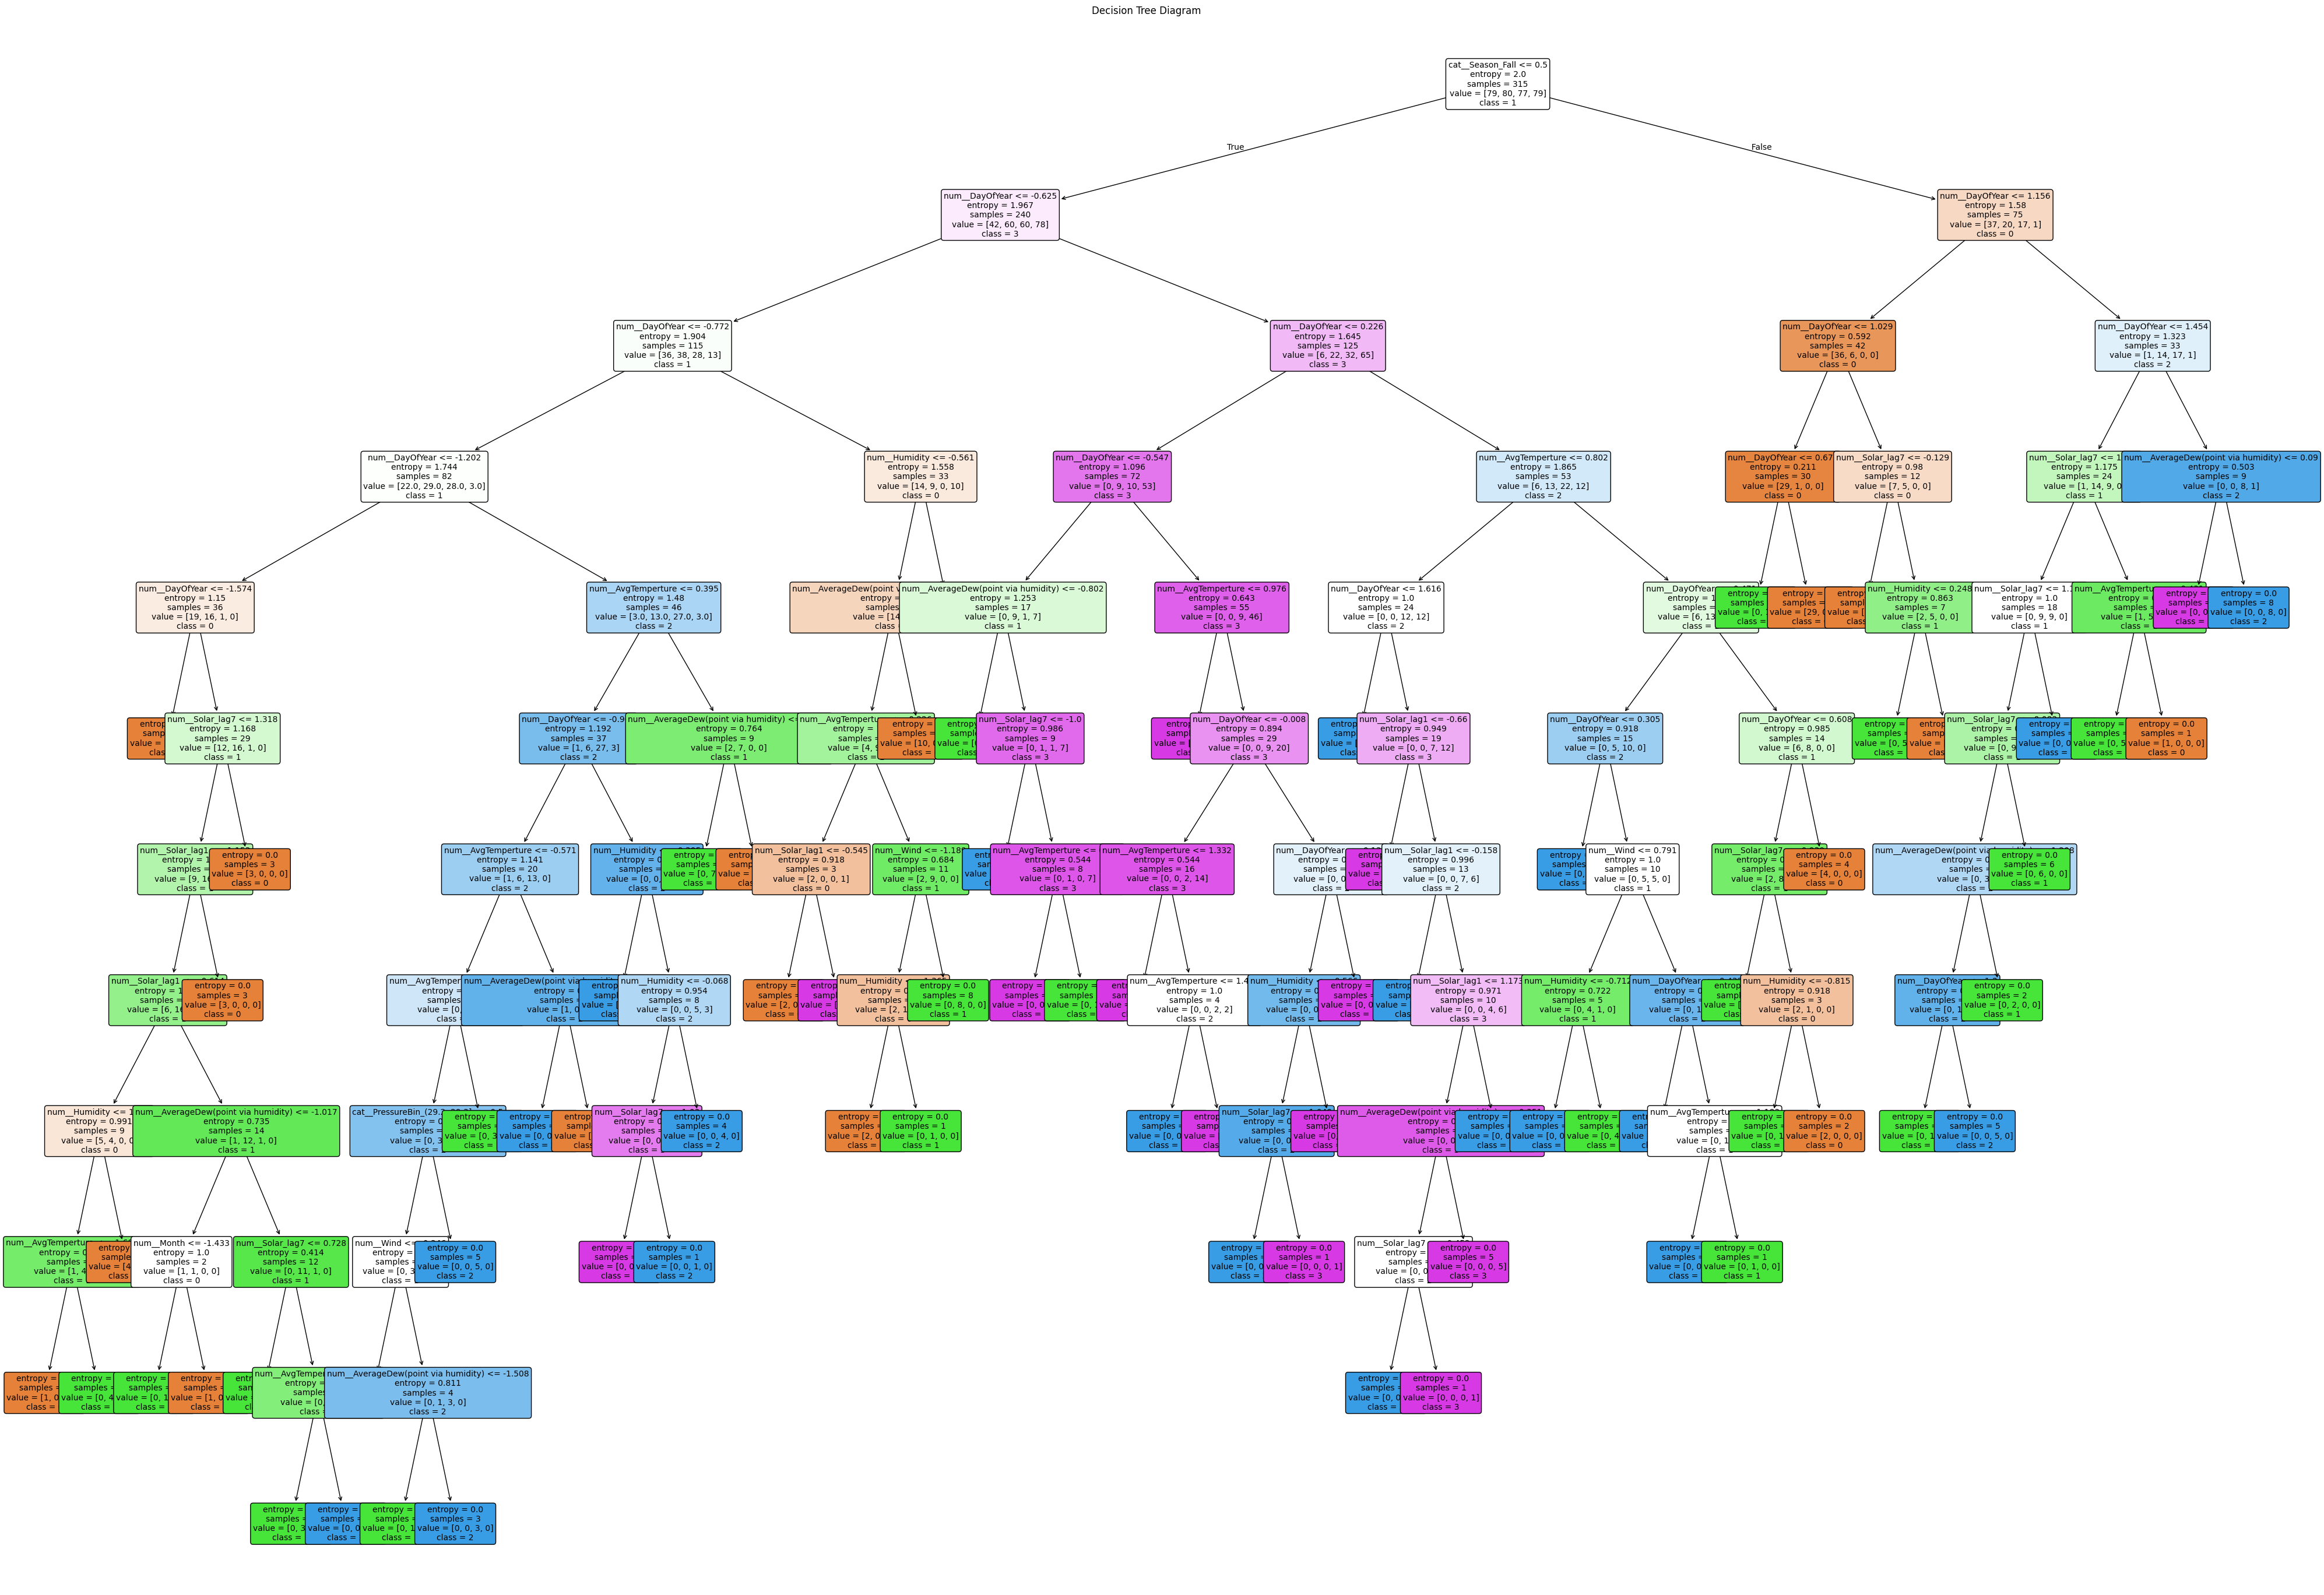

In [61]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_model = pipeline.named_steps["model"]

plt.figure(figsize=(50, 35))
plot_tree(
    dt_model, 
    filled=True,         
    rounded=True,       
    fontsize=10,
    feature_names=pipeline.named_steps["preprocess"].get_feature_names_out(),
    class_names=[str(c) for c in sorted(y_train_class.unique())]
)

plt.title("Decision Tree Diagram")
plt.show()


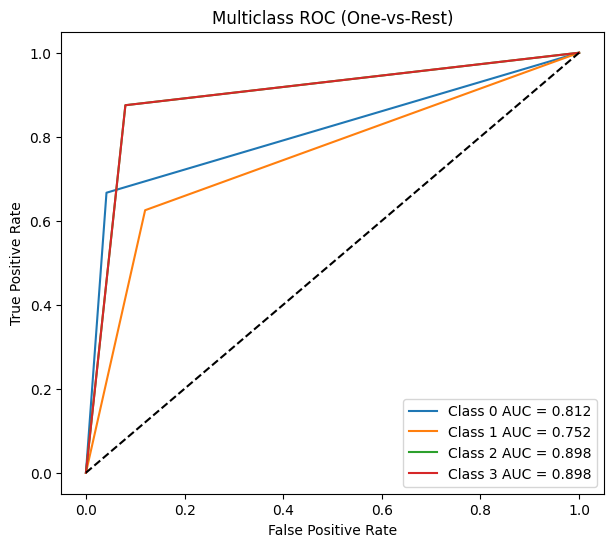

In [62]:
classes = sorted(y_test_class.unique())
y_test_bin = label_binarize(y_test_class, classes=classes)

y_prob = pipeline.predict_proba(x_test)

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7, 6))
for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {cls} AUC = {roc_auc[i]:.3f}")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC (One-vs-Rest)")
plt.legend()
plt.show()


### Model Performance Interpretation

The model achieved an **accuracy of 1.0 (100%) on the training set**, while obtaining approximately **0.76 (76%) accuracy on both the validation and test sets**.

This pattern indicates **overfitting**.

- The perfect performance on the training data suggests that the model has essentially **memorized** the training examples rather than learning generalizable patterns.
- The significantly lower performance on unseen data (validation and test) shows that the learned relationships do **not transfer well** beyond the training set.
- In other words, the model is capturing **noise and specific quirks** of the training data instead of learning stable structure in the underlying process.

A well-generalizing model would exhibit **similar accuracy across training, validation, and test sets** with only a small gap between them. Here, the gap is large (100% → 76%), clearly pointing to high variance and overfitting behavior.
